# Introduction

The increasing prevalence of social media use among students has raised concerns about its potential effects on academic performance and mental health. Social media platforms are widely used for communication, entertainment, and information sharing, but excessive use may lead to distractions, interpersonal conflict, and symptoms associated with social media addiction. As a result, understanding how patterns of social media use relate to student outcomes has become an important area of study.

This project analyzes a student social media dataset to examine how different patterns of social media use are associated with academic performance and mental health outcomes. The dataset includes variables related to social media behavior, such as `average daily usage,` `most-used platforms,` `conflicts caused by social media,` and whether students perceive themselves as addicted to social media. In addition, demographic characteristics, including `age,` `gender,` `education level,` and `country of residence,` are included to explore whether these factors influence the relationship between social media use and student outcomes.

Through statistical analysis, this study aimed to identify potentially harmful patterns of social media use that may be associated with poorer academic performance and negative mental health indicators. The analysis also examined whether these relationships differed across demographic groups, such as `age,` `gender,` `education level,` and `geographic region.`

The primary research question was whether higher levels of social media usage, conflict related to social media, or self-perceived addiction behaviors were associated with poorer mental health among students. We hypothesized that greater daily social media use and higher indicators of conflict or addiction will be associated with poorer mental health outcomes. Additionally, it was expected that demographic factors — particularly `education level` — may moderate these relationships, potentially reducing the strength of harmful associations among students at higher education levels.

**Research Question 1:** Are `higher levels of social media use,` `conflict,` or `self-percieved addiction` associated with `poorer mental health status` among students?

**Research Question 2:** Did associations of `social media,` `conflict,` and `academic performance` differ across demographic subgroups (`age,` `gender,` `education level,` and `country group`)?


In [1]:
#Load Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import statsmodels.api as sm

In [2]:
#Load Source Code
import data_cleaning as dc
import exploratory_analysis as ea
import modeling as md

# Dataset Description

The dataset "Students' Social Media Addiction" from Kaggle looked to analyze students social media usage and the impact it had on various aspects of their life such as academic performance, social and mental health, and sleep. The dataset included 12 variables, including `age,` `gender,` `academic level,` `country,` `average daily usage hours,` `most used platform,` affected `academic performance,` `sleep hours per night,` `mental health score,` `relationship status,` `conflicts over social media,` and `addiction score.`

These variables were crucial for understanding the relationship between `social media usage` and `mental health scores` because they combined self reported and calculated metrics to ensure accruacy. By understanding the relationship between social media usage, demographics, and mental health, it can be determined whether this data supports other studies findings that greater social media usage truly decreases mental health (Khalaf et al., 2023). 

In [3]:
#Load Data
df = pd.read_csv('Students Social Media Addiction.csv')
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


# Preprocessing

In [4]:
#NA Removal
df.isna().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

There appeared to be no `null` or `missing values` in the dataset that must be removed. Additionally, after manually examining all 705 respondants, all answers appeared to be consistent and truthful. 

In [5]:
# Outlier Removal
df_clean = dc.clean_data(df)
df_clean.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000
mean,353.096866,20.659544,4.913533,6.875926,6.226496,2.850427,6.435897
std,203.541208,1.397793,1.239162,1.116842,1.100504,0.951982,1.575768
min,1.000000,18.000000,2.000000,4.000000,4.000000,0.000000,3.000000
25%,177.250000,19.250000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,352.500000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.750000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.300000,9.600000,8.000000,5.000000,9.000000


3 Outliers were removed based on a 1.5 * IQR method to ensure data accuracy and a roughly normal distribution. 

# Exploratory Data Analysis

### Mental Health Score Distribution

Summary Statistics:
count    702.000000
mean       6.226496
std        1.100504
min        4.000000
25%        5.000000
50%        6.000000
75%        7.000000
max        8.000000
Name: Mental_Health_Score, dtype: float64


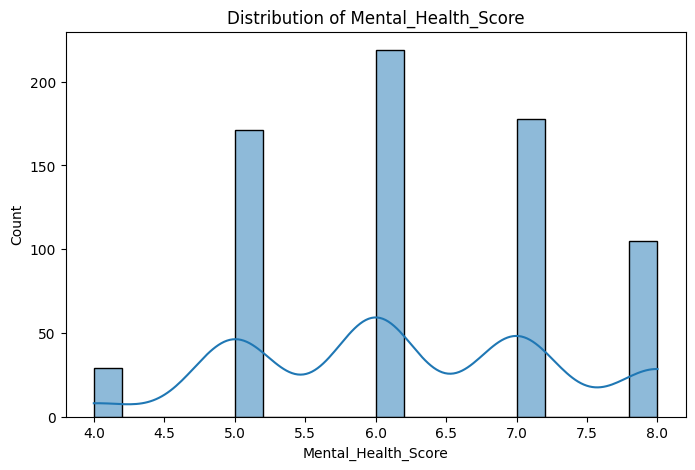

In [6]:
ea.summarize_variable(df_clean,"Mental_Health_Score")

Mental Health Scores were centered around a value of 6.23 with a minimum value of 4 and a maximum value of 8. Additionally, the median of 6 is relatively close to the mean value of 6.23, implying little to no skewness in either direction and showed that the distribution appears to be roughly normal.

### Correlation Between Usage and Mental Health

Pearson correlation between `Avg_Daily_Usage_Hours` and `Mental_Health_Score`: -0.801


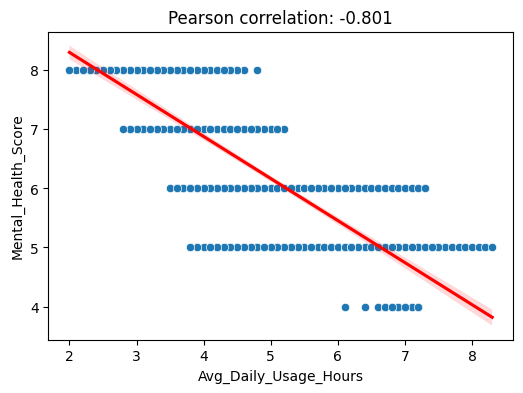

np.float64(-0.8007189310136091)

In [7]:
ea.correlate(df_clean,"Avg_Daily_Usage_Hours","Mental_Health_Score")

We observed an incredibly strong, negative correlation between `average daily usage` of social media (no matter the platform) and lower `mental health scores` with a pearson correlation of -0.801. This strong correlation demonstrated that higher usage was related to worse mental health. We further explored this relationship in model building for this project.

### Correlation Between Addiction and Mental Health

Pearson correlation between `Addicted_Score` and `Mental_Health_Score`: -0.945


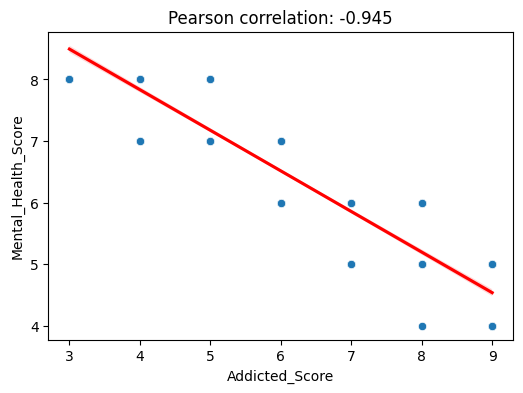

np.float64(-0.9446181789142617)

In [8]:
ea.correlate(df_clean,"Addicted_Score","Mental_Health_Score")

Similar to the correlation calculated between mental health score and average social media usage, social media addiction score and mental health are even more strongly negatively correlated with a pearson value of -0.945. This further supports the hypothesis that greater consumption of social media negatively impacts social media.

### Correlation Between Conflict and Mental Health

Pearson correlation between 'Conflicts_Over_Social_Media' and 'Mental_Health_Score': -0.892


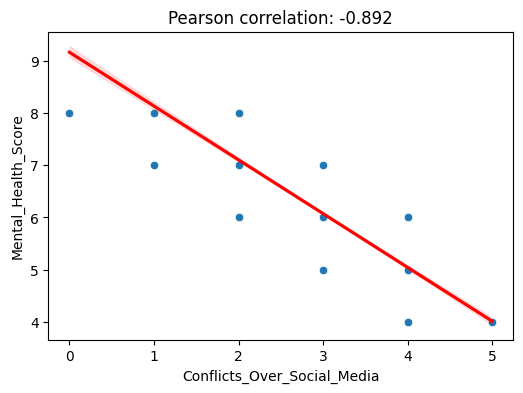

np.float64(-0.8921698547683025)

In [9]:
ea.correlate(df_clean,"Conflicts_Over_Social_Media","Mental_Health_Score")

There appears to be an incredibly strong, negative correlation between conflicts caused by social media and lower mental health scores with a pearson correlation of -0.892. This strong correlation demonstrates that higher conflict induced by social media is related to worse mental health. This relationship will be further explored in model building.

### Correlation Between Age and Mental Health

Pearson correlation between 'Age' and 'Mental_Health_Score': 0.153


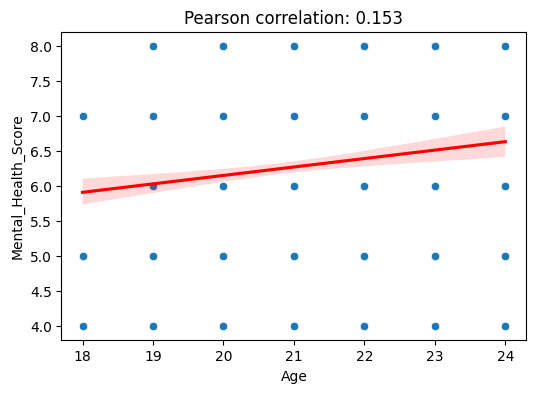

np.float64(0.15313700056971938)

In [10]:
ea.correlate(df_clean,"Age","Mental_Health_Score")

There appears to be a slight, positive correlation between age and mental health score shown by a pearson correlation of 0.153. However, this relationship does not appear to be strong and most likely occured by random chance rather than statistical significance. Thus, age will not be included in the final regression model.

### Platform Usage Patterns

Comparing 'Mental_Health_Score' across 12 groups of 'Most_Used_Platform': ['Facebook', 'Instagram', 'KakaoTalk', 'LINE', 'LinkedIn', 'Snapchat', 'TikTok', 'Twitter', 'VKontakte', 'WeChat', 'WhatsApp', 'YouTube']


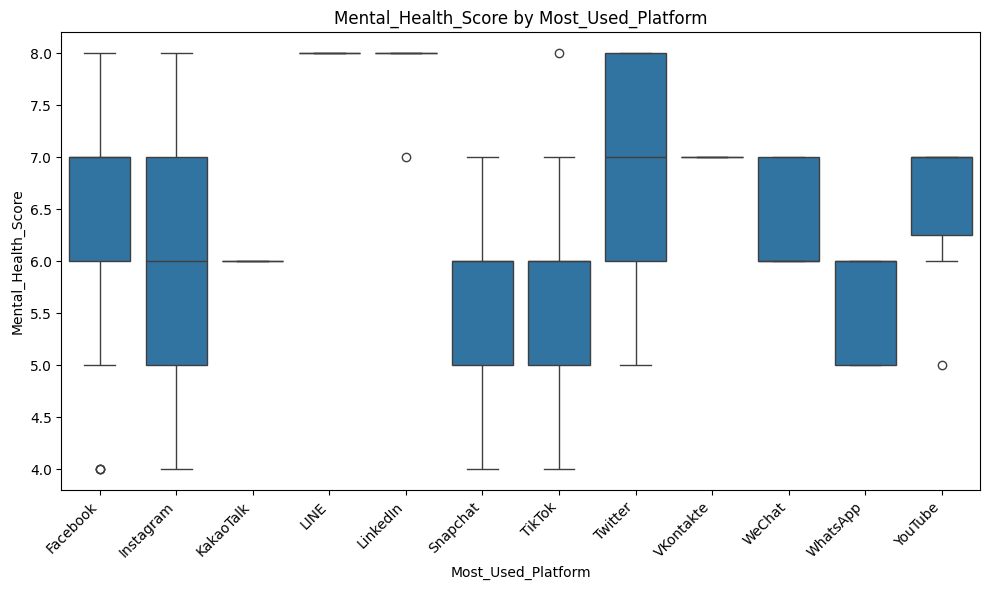

One-way ANOVA result: F = 22.109, p = 0.0000


(np.float64(22.10914816748988), np.float64(7.354057944969391e-39))

In [11]:
ea.compare(df_clean,"Mental_Health_Score","Most_Used_Platform")

Based on the ANOVA test conducted, there appears to be a statically significant difference in mental health scores based on the most used social media platform with an F-statistic of 22.11 and a p-value of 0.00. As seen in the visual, individuals that use Twitter the most tend to have the greatest mental health scores while individuals that use Snapchat and TikTok the most have the lowest mental health scores. This statistically significant relationship between most used platform and mental health scores may create an interaction effect with average hours spent and should be explored in the regression model.

### Academic Impact Patterns

Comparing 'Mental_Health_Score' across 2 groups of 'Affects_Academic_Performance': ['No', 'Yes']


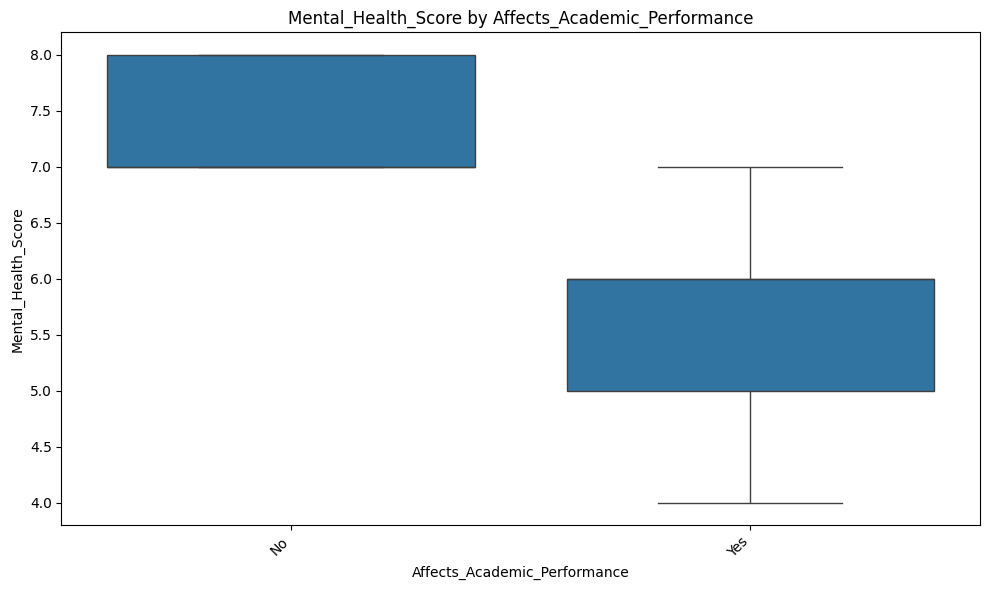

T-test (Welch) result: t = 40.280, p = 0.0000


(np.float64(40.280172648122665), np.float64(4.139096563827149e-181))

In [12]:
ea.compare(df_clean,"Mental_Health_Score","Affects_Academic_Performance")

Based on the t-test  conducted, there does appear to be a statistically significant difference in mental health scores based on whether social media impacts and individuals academic performance with a T-statistic of 40.28 and a p-value of 0.00. As seen by the boxplot comparing both, the difference appears to be incredibly strong with individuals that answered "Yes" to their academics being impacted having much lower average mental health scores. This analysis demonstrates that individuals with higher amounts of social media usage that believe this social media usage is impacting their academics are more likely to have worse mental health than individuals that do not believe their social media usage is impacting their academic performance.

### Demographic Analysis

Comparing 'Mental_Health_Score' across 2 groups of 'Gender': ['Female', 'Male']


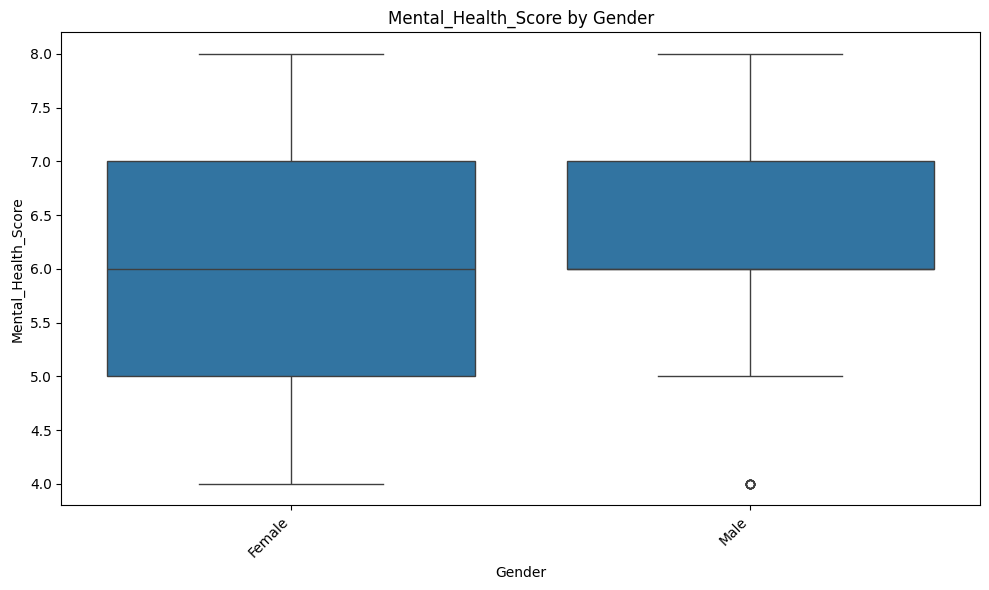

T-test (Welch) result: t = -1.063, p = 0.2880


(np.float64(-1.0632662101494033), np.float64(0.28803396613377685))

In [13]:
ea.compare(df_clean,"Mental_Health_Score","Gender")

Based on the t-test conducted to determine whether there is a relationship between gender and mental health score, there does not appear to be a statistically significant relationship between these variables with a p-value of 0.29. Thus, gender does not appear to have a significant impact on mental health and should not be included in the final model.

Comparing 'Mental_Health_Score' across 3 groups of 'Academic_Level': ['Graduate', 'High School', 'Undergraduate']


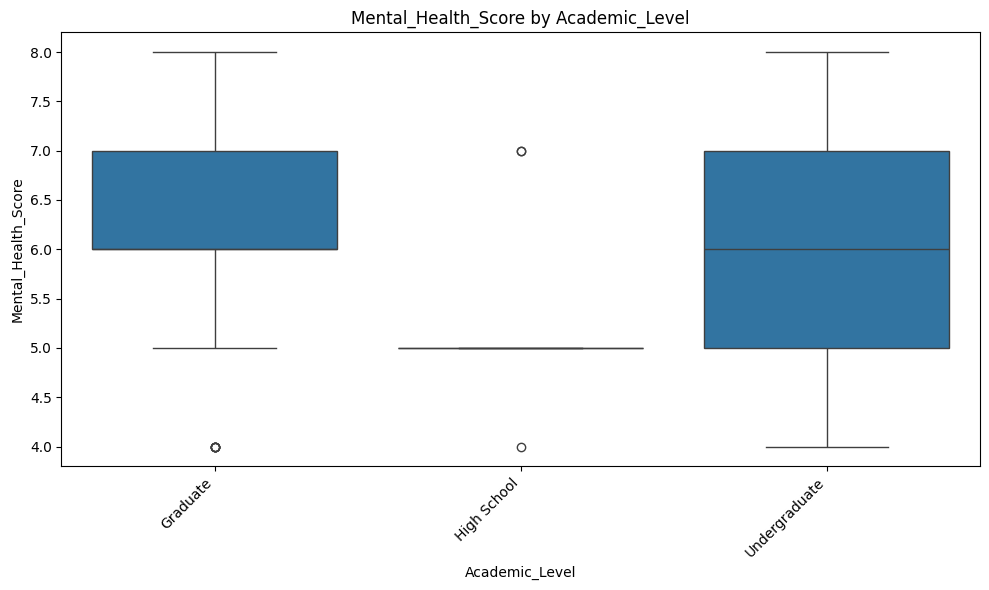

One-way ANOVA result: F = 17.432, p = 0.0000


(np.float64(17.4318416160411), np.float64(4.09441564190084e-08))

In [14]:
ea.compare(df_clean,"Mental_Health_Score","Academic_Level")

Based on the ANOVA test, there appears to be a statistically significant relationship between mental health scores and academic level shown by the F-statistic of 17.43 and p-value of 0.00. This difference can also be seen in the visual with graduate students having the highest average mental health score and high school students having the lowest average. While this realtionship is statistically significant, graduate and undergraduate students do not appear to differ much and thus, this relationship will be examined further in regression model building to determine which of the 3 groups should be included in the model as dummies.

# Model Building

Based on the initial exploratory analysis and logical selection, the following variables were found to have relation to mental health scores: conflicts over social media, academic level, average daily usage, most used platform, affects academic performance, and sleep hours per night. 

However, most used platform and sleep hours per night were omitted from the data. Sleep hours per night and relationship status were omitted because they were not directly related to social media usage enough and may have skewed the data away from the primary goal of comparing social media usage with mental health scores.

Thus, the regression model building began with the following variables: academic level, average daily usage, most used platform, and affect academic performance. The model was adapted as modeling was done to create the best performing model.

### Create Dummy Variables

In [15]:
df_dummy1 = md.dummies(df_clean, "Most_Used_Platform")
df_dummy2 = md.dummies(df_dummy1, "Academic_Level")
df_dummy3 = md.dummies(df_dummy2, "Affects_Academic_Performance")
print(df_dummy3.head())

   Student_ID  Age  Gender     Country  Avg_Daily_Usage_Hours  \
0           1   19  Female  Bangladesh                    5.2   
1           2   22    Male       India                    2.1   
2           3   20  Female         USA                    6.0   
3           4   18    Male          UK                    3.0   
4           5   21    Male      Canada                    4.5   

   Sleep_Hours_Per_Night  Mental_Health_Score Relationship_Status  \
0                    6.5                    6     In Relationship   
1                    7.5                    8              Single   
2                    5.0                    5         Complicated   
3                    7.0                    7              Single   
4                    6.0                    6     In Relationship   

   Conflicts_Over_Social_Media  Addicted_Score  ...  \
0                            3               8  ...   
1                            0               3  ...   
2                            

### Full Multiple Linear Regression Model

In [16]:
full_predictors = [
    "Avg_Daily_Usage_Hours", 
    "Affects_Academic_Performance_Yes", 
    "Most_Used_Platform_Twitter", 
    "Most_Used_Platform_TikTok", 
    "Most_Used_Platform_Snapchat", 
    "Addicted_Score", 
    "Conflicts_Over_Social_Media", 
    "Academic_Level_High School"
]

full_model = md.regression(df_dummy3, "Mental_Health_Score", full_predictors)

                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.899
Model:                             OLS   Adj. R-squared:                  0.898
Method:                  Least Squares   F-statistic:                     771.1
Date:                 Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                         18:09:07   Log-Likelihood:                -258.10
No. Observations:                  702   AIC:                             534.2
Df Residuals:                      693   BIC:                             575.2
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

### Significant Multiple Linear Regression Model

In [17]:
sig_predictors = [
    "Most_Used_Platform_TikTok", 
    "Addicted_Score", 
    "Conflicts_Over_Social_Media", 
]

sig_model = md.regression(df_dummy3, "Mental_Health_Score", sig_predictors)

                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.898
Model:                             OLS   Adj. R-squared:                  0.898
Method:                  Least Squares   F-statistic:                     2057.
Date:                 Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                         18:09:07   Log-Likelihood:                -260.27
No. Observations:                  702   AIC:                             528.5
Df Residuals:                      698   BIC:                             546.8
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const   

Based on both models produced, it seems that the strongest predictors of mental health score are addiction scores and conflicts caused by social media followed by TikTok usage. Both addiction score and conflicts have negative coefficients, demonstrating a negative correlation. As conflict and addiction increases, mental health scores decrease. This makes the most sense because logically, when addiction and conflicts are higher, mental health is expected to decrease. Additionally, these variables encapsulate average social media usage because higher social media is correlated with greater conflict and sense of addiction. Thus, while average social media usage was not statistically significant in the full model, it is most likely still being factored in through these 2 variables. Finally, it seems that TikTok usage improves mental health scores compared to other social media platforms. While this may be coincidence, it could be interesting to study TikTok further to determine what it does differently to other social media sites that allow it to improve mental health.

When looking at adjusted r-sqaured, both the full and significant models are similar, with values of 0.898 and 0.899. Both models account for roughly 90% of the variation in mental health scores. This is a very strong adjusted r-squared and demonstrates that the model has very strong descriptive power.

While the model has strong descriptive power, it may be overfitting the data and not be good at predicting future data. To create a predictive model, data would need to be split into training and validation sets to allow for predictive testing. However, this dataset only has 702 applicable data points. Thus, splitting the data would be ineffective because the subset datasets would be too small to produce actionable results.

### Regression Assumption Checks

Before interpreting the regression results, three key OLS assumptions are verified:

1. **Normality of residuals** — residuals should be approximately normally distributed.
2. **Homoscedasticity** — residuals should have roughly constant variance across fitted values.
3. **No severe multicollinearity** — predictors should not be excessively correlated with each other (checked using Variance Inflation Factor, VIF).

#### 1. Normality of Residuals

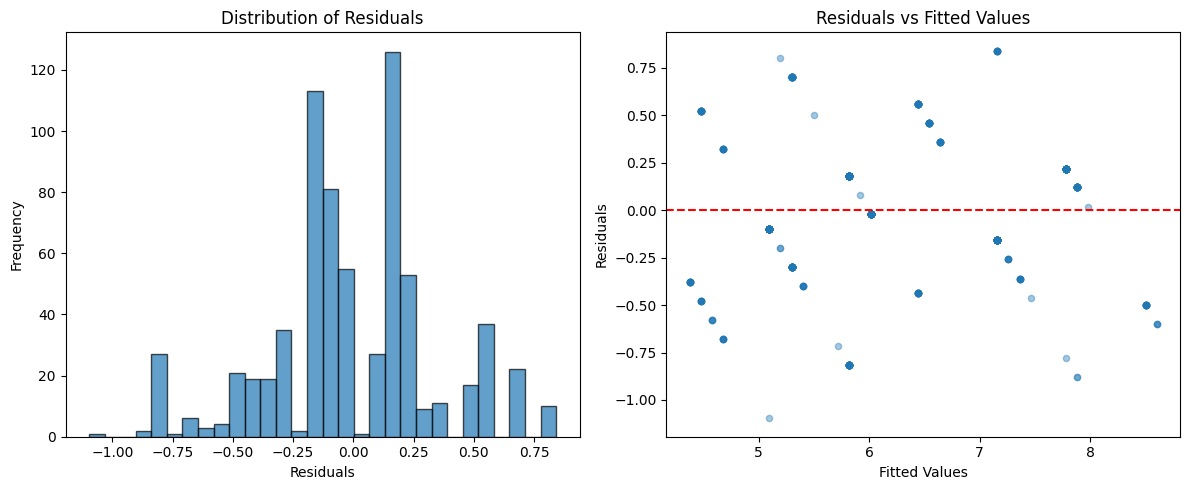

In [18]:
residuals = sig_model.resid
fitted = sig_model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of residuals
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Residuals')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

# Residuals vs Fitted
axes[1].scatter(fitted, residuals, alpha=0.4, s=20)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Fitted Values')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

The residual histogram shows an approximately bell-shaped, symmetric distribution centered near zero, suggesting the normality assumption is reasonably satisfied. The residuals vs. fitted values plot shows residuals scattered randomly around zero with no clear pattern, indicating the homoscedasticity assumption is also met. This is further supported by the Omnibus and Jarque-Bera statistics in the regression summary above (p = 0.148 and p = 0.152 respectively), both of which fail to reject normality at the 5% significance level.

#### 2. Multicollinearity (VIF)

In [19]:
vif_result = md.check_vif(df_dummy3, sig_predictors)
print(vif_result)

                      Variable       VIF
0               Addicted_Score  7.802772
1  Conflicts_Over_Social_Media  7.684791
2    Most_Used_Platform_TikTok  1.121679


The VIF results show that `Addicted_Score` and `Conflicts_Over_Social_Media` have moderate multicollinearity with each other — this is expected, since higher social media use tends to drive both higher addiction scores and more conflicts. Both values remain below the conventional threshold of 10, indicating that multicollinearity, while present, is not severe enough to invalidate the model's coefficient estimates. `Most_Used_Platform_TikTok` shows virtually no collinearity with the other predictors.

# Conclusion

Overall, the exploratory analysis and model building came to the same conclusion; greater social media usage is related to lower mental health scores. Supporting the hypothesis from **Research Question 1**. 

Correlation between social media usage, conflicts caused by social media usage, and addiction scores all produced very low pearson correlation values showing strong, negative correlation. Additionally, all 3 of these variables, while not all statistically significant, had negative coefficients in the full regression model. This shows that higher social media usage is linked with lower mental health scores for the students in this study across all demographics and platforms used. These conclusions were further supported by the strong adjusted r-squared of the regression models produced. Thus, it can be concluded with relative certainty that, from the data in this study, individuals with higher social media usage tended to have lower mental health scores. 

Alongside this finding, some variables seemed to further or lessen this relationship. For example, individuals in high school seemed to have an overall lower mental health score shown by the ANOVA and by the regression model. Additionally, certain social media platforms showed signs of causing more or less harm to mental health. TikTok seemed to be the best for mental health.

However, unlike the initial hypothesis from **Research Question 2**, demographics did not seem to have much of an impact on mental health scores. In the exploratory analysis stage, age, country, and academic level seemed to have little to no effect on mental health scores. Furthermore, these variables provided no interaction effect when introduced into the regression model. Thus, it cannot be concluded based on the data from this study that demographics have any impact on mental health scores.

# Limitations

While this study produced strong statistical results, several important limitations regarding the appropriateness, reliability, and validity of the chosen methods and results should be acknowledged.

**Appropriateness of Methods:**
Pearson correlation, Welch's t-test, one-way ANOVA, and OLS regression were all appropriate choices for this data given the numeric and categorical variable types present. However, OLS regression assumes a linear relationship between predictors and the response variable. While this assumption appears reasonable here, the true relationship between social media use and mental health may be non-linear. Additionally, the mental health score is a discrete integer scale (4–9) rather than a true continuous variable, which slightly violates the strict assumptions of OLS. A ordinal regression model could have been a more technically appropriate choice, though OLS remains widely accepted for similarly structured outcome variables.

**Reliability of Results:**
The dataset was sourced from Kaggle and consists entirely of self-reported responses. Self-reported data introduces the risk of response bias — participants may over- or under-report their social media use, addiction levels, or mental health in ways that are difficult to detect or correct. The sampling method is unknown, meaning the sample may not be representative of the broader student population. Additionally, with only 702 observations after outlier removal, the dataset is relatively small, which limits the stability of the regression coefficients and reduces the statistical power available for detecting smaller effects. The strong correlations found (Pearson r > 0.80) may also partially reflect how the dataset was constructed rather than a true population-level effect.

**Validity of Results:**
The most important validity concern is that this study is entirely correlational. While strong associations were found between social media usage, addiction scores, conflict, and mental health scores, no causal conclusions can be drawn. It is equally plausible that individuals with poorer mental health are more likely to use social media excessively, rather than social media use causing poor mental health. Establishing causation would require a longitudinal or experimental study design. Furthermore, the study does not account for potential confounding variables such as socioeconomic status, pre-existing mental health conditions, or offline social support networks, all of which could influence both social media use and mental health outcomes.

Despite these limitations, the findings are consistent with existing literature on the relationship between social media use and mental health, and the strong adjusted R-squared of approximately 0.90 suggests the model captures a meaningful portion of the variation in mental health scores within this dataset.